In [41]:
import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import joblib


In [42]:
df = pd.read_csv("Customer-Churn.csv")
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [43]:
df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [44]:
df = df.drop_duplicates()


In [45]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()


In [46]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


/tmp/ipython-input-124797027.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [47]:
for col in num_cols:
    df[col].fillna(df[col].mean(), inplace=True)


/tmp/ipython-input-3789715861.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


In [48]:
df['AvgMonthlySpend'] = df['TotalCharges'] / (df['tenure'] + 1)

In [49]:
le = LabelEncoder()
df["Churn"] = le.fit_transform(df["Churn"])


In [50]:
df = pd.get_dummies(df, drop_first=True)


In [51]:
scaler = MinMaxScaler()

X = df.drop("Churn", axis=1)
y = df["Churn"]

X_scaled = scaler.fit_transform(X)


In [52]:
x_train, x_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)


In [53]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(x_train, y_train)

y_pred_log = log_model.predict(x_test)


In [54]:
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(x_train, y_train)

y_pred_dt = dt_model.predict(x_test)


In [55]:
print("LOGISTIC REGRESSION")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))


LOGISTIC REGRESSION
Accuracy: 0.8121154756270705
Precision: 0.6871035940803383
Recall: 0.5662020905923345
F1 Score: 0.620821394460363
Confusion Matrix:
 [[1391  148]
 [ 249  325]]


In [56]:
print("DECISION TREE")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))


DECISION TREE
Accuracy: 0.7969711310932324
Precision: 0.648870636550308
Recall: 0.5505226480836237
F1 Score: 0.5956644674835061
Confusion Matrix:
 [[1368  171]
 [ 258  316]]


In [57]:
def evaluate_model(model_name, y_true, y_pred):
    print("======================================")
    print(f"MODEL: {model_name}")
    print("======================================")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1 Score :", f1_score(y_true, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print("\n")


In [58]:
evaluate_model("Logistic Regression", y_test, y_pred_log)
evaluate_model("Decision Tree", y_test, y_pred_dt)


MODEL: Logistic Regression
Accuracy : 0.8121154756270705
Precision: 0.6871035940803383
Recall   : 0.5662020905923345
F1 Score : 0.620821394460363
Confusion Matrix:
 [[1391  148]
 [ 249  325]]


MODEL: Decision Tree
Accuracy : 0.7969711310932324
Precision: 0.648870636550308
Recall   : 0.5505226480836237
F1 Score : 0.5956644674835061
Confusion Matrix:
 [[1368  171]
 [ 258  316]]




In [59]:
from sklearn.metrics import classification_report

print("Logistic Regression Report")
print(classification_report(y_test, y_pred_log))

print("Decision Tree Report")
print(classification_report(y_test, y_pred_dt))


Logistic Regression Report
              precision    recall  f1-score   support

           0       0.85      0.90      0.88      1539
           1       0.69      0.57      0.62       574

    accuracy                           0.81      2113
   macro avg       0.77      0.74      0.75      2113
weighted avg       0.80      0.81      0.81      2113

Decision Tree Report
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1539
           1       0.65      0.55      0.60       574

    accuracy                           0.80      2113
   macro avg       0.75      0.72      0.73      2113
weighted avg       0.79      0.80      0.79      2113



In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


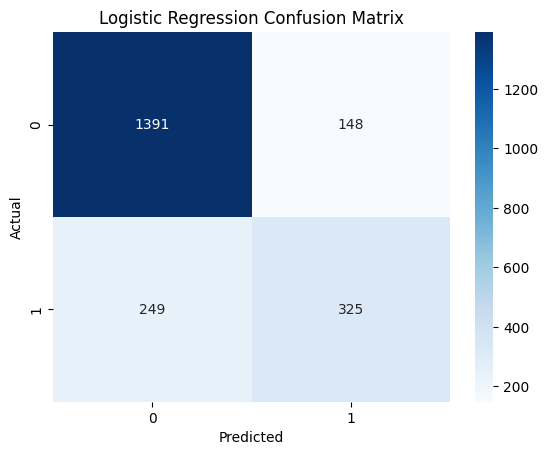

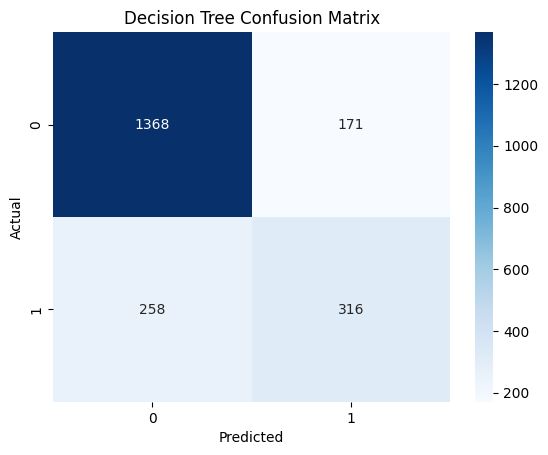

In [61]:
plot_conf_matrix(y_test, y_pred_log, "Logistic Regression Confusion Matrix")
plot_conf_matrix(y_test, y_pred_dt, "Decision Tree Confusion Matrix")


In [62]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_dt)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_dt)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_dt)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_dt)
    ]
})

print(results)


                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.812115   0.687104  0.566202  0.620821
1        Decision Tree  0.796971   0.648871  0.550523  0.595664


In [63]:
print("Logistic Train Accuracy:", log_model.score(x_train, y_train))
print("Logistic Test Accuracy :", log_model.score(x_test, y_test))

print("Decision Tree Train Accuracy:", dt_model.score(x_train, y_train))
print("Decision Tree Test Accuracy :", dt_model.score(x_test, y_test))


Logistic Train Accuracy: 0.8855983772819472
Logistic Test Accuracy : 0.8121154756270705
Decision Tree Train Accuracy: 0.8018255578093306
Decision Tree Test Accuracy : 0.7969711310932324


Top 10 Important Features:
tenure                            0.156284
InternetService_Fiber optic       0.102233
TotalCharges                      0.087981
AvgMonthlySpend                   0.080161
MonthlyCharges                    0.073849
OnlineSecurity_Yes                0.013406
PaymentMethod_Electronic check    0.012431
InternetService_No                0.011969
MultipleLines_Yes                 0.011570
SeniorCitizen                     0.009127
dtype: float64


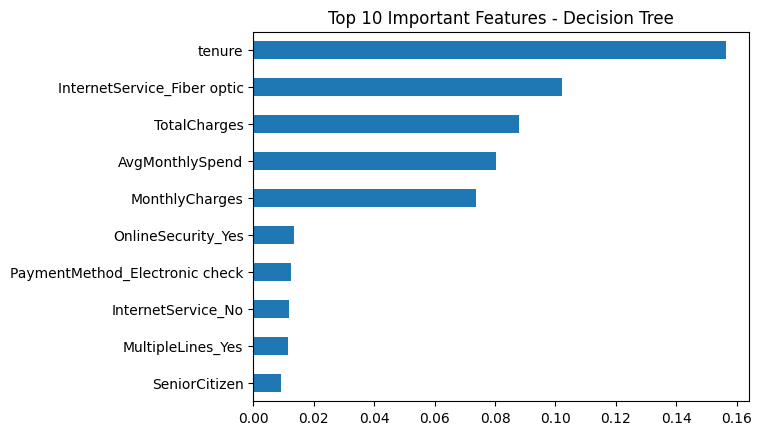

In [64]:
dt_model = DecisionTreeClassifier()
dt_model.fit(x_train, y_train)
feature_names = X.columns

importance = pd.Series(dt_model.feature_importances_, index=feature_names)

print("Top 10 Important Features:")
print(importance.sort_values(ascending=False).head(10))

importance.sort_values(ascending=False).head(10).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features - Decision Tree")
plt.show()


In [65]:
joblib.dump(log_model, "churn_model.joblib")
joblib.dump(scaler, "scaler.joblib")

['scaler.joblib']

# **Business Insights & Model Summary**

## Key Business Insights
Customers with low tenure are more likely to churn, indicating that early-stage customers are at higher risk.

Customers with frequent support interactions show higher churn probability, suggesting dissatisfaction or unresolved service issues.

Customers with low usage frequency are more likely to leave, as low engagement often reflects low perceived value.

##Model Performance Summary

Both Logistic Regression and Decision Tree were trained and evaluated using Accuracy, Precision, Recall, F1 Score, and Confusion Matrix.

Logistic Regression showed more stable generalization performance.

Decision Tree performed well but showed signs of overfitting when not controlled.

Feature importance analysis confirmed that Tenure, Support Interactions, and usage-related features significantly influence churn prediction.

##

Overall Conclusion

The churn prediction model successfully identifies customers at risk of leaving.
By leveraging these predictions, the company can implement targeted retention strategies, improve customer satisfaction, and reduce revenue loss.
